# ALttPR Analysis

Analyzing a set of 28k ALttPR games generated by https://github.com/sporchia/alttp_vt_randomizer (https://alttpr.com)

Games inspected by Mudora (https://github.com/alttpr-mudora/mudora)

## Install dependencies and download dataset

In [1]:
import pandas as pd
import kagglehub
from pathlib import Path

# Download latest version
path = kagglehub.dataset_download("typorter/a-link-to-the-past-randomizer-item-locations")

alttpr_csv = Path(path) / "alttpr.csv"

print("Path to alttpr.csv:", alttpr_csv)

Path to alttpr.csv: C:\Users\tyler\.cache\kagglehub\datasets\typorter\a-link-to-the-past-randomizer-item-locations\versions\1\alttpr.csv


In [2]:
df = pd.read_csv(alttpr_csv, index_col=0)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 28193 entries, 0 to 28192
Columns: 228 entries, GameId to Pyramid Bottle
dtypes: object(228)
memory usage: 49.3+ MB


,GameId,Sahasrahla's Hut - Left,Sahasrahla's Hut - Middle,Sahasrahla's Hut - Right,Sahasrahla,Zora's Ledge,Waterfall Fairy - Left,Waterfall Fairy - Right,Master Sword Pedestal,King's Tomb,...,Ganon's Tower - Compass Room - Bottom Right,Ganon's Tower - Big Key Chest,Ganon's Tower - Big Key Room - Left,Ganon's Tower - Big Key Room - Right,Ganon's Tower - Mini Helmasaur Room - Left,Ganon's Tower - Mini Helmasaur Room - Right,Ganon's Tower - Pre-Moldorm Chest,Ganon's Tower - Moldorm Chest,Waterfall Bottle,Pyramid Bottle
0,z232byRRkpnx3Ao,Piece of Heart,Boomerang,Progressive Armor,Piece of Heart,Progressive Shield,Heart Container,Piece of Heart,Arrows (10),Fire Rod,...,Key (Ganon's Tower),Bombs (3),Arrows (10),Rupee (Red),Heart Container,Rupees (50),Bombs (3),Compass (Ganon's Tower),Bottle (Blue Potion),Bottle (Green Potion)
1,1xXJNBQBNaPeXWP,Rupee (Red),Progressive Shield,Rupee (Red),Piece of Heart,Rupees (100),Piece of Heart,Bombs (3),Heart Container,Piece of Heart,...,Bombs (3),Heart Container,Book of Mudora,Piece of Heart,Piece of Heart,Rupees (50),Rupee (Red),Rupee (Red),Bottle (Red Potion),Bottle (Green Potion)
2,mOX4bAYYnLowq0v,Rupees (300),Cane of Somaria,Arrows (10),Rupee (Red),Bottle (Faerie),Rupees (300),Bombs (3),Bottle (Green Potion),Progressive Sword,...,Rupee (Green),Rupee (Red),Big Key (Ganon's Tower),Arrows (10),Powder,Rupee (Red),Compass (Ganon's Tower),Rupees (50),Bottle (Green Potion),Bottle (Bee)
3,vPlbLrZrrL4K3a0,Piece of Heart,Bombs (3),Rupees (100),Rupee (Green),Rupees (50),Piece of Heart,Piece of Heart,Rupee (Red),Piece of Heart,...,Bombs (3),Big Key (Ganon's Tower),Piece of Heart,Bombs (3),Book of Mudora,Key (Ganon's Tower),Heart Container,Rupee (Red),Bottle (Bee),Bottle (Blue Potion)
4,JbqRx1Qd5jKpXm5,Rupees (50),Quake,Rupee (Red),Arrows (10),Piece of Heart,Rupees (300),Piece of Heart,Rupee (Red),Piece of Heart,...,Arrows (10),Piece of Heart,Heart Container,Rupee (Red),Piece of Heart,Progressive Shield,Piece of Heart,Rupee (Red),Bottle (Super bee),Bottle (Green Potion)


## Unique items

Now get a list of unique cell values. We will compute the chance that an item shows up at a location later as well as filter out some values by removing non-progression items from analysis.

In [3]:
# Get a list of unique items
item_cols = df.columns.drop("GameId")

unique_items = sorted(pd.unique(df[item_cols].values.ravel()))

## Calculate the chance that an item lands at a position

(scaled to 0 - 100)

In [4]:
# % of games in which each item lands at each location
pct = pd.DataFrame({
    col: df[col].value_counts(normalize=True) * 100
    for col in item_cols
}).reindex(index=unique_items, columns=item_cols).fillna(0)

pct

,Sahasrahla's Hut - Left,Sahasrahla's Hut - Middle,Sahasrahla's Hut - Right,Sahasrahla,Zora's Ledge,Waterfall Fairy - Left,Waterfall Fairy - Right,Master Sword Pedestal,King's Tomb,Kakariko Tavern,...,Ganon's Tower - Compass Room - Bottom Right,Ganon's Tower - Big Key Chest,Ganon's Tower - Big Key Room - Left,Ganon's Tower - Big Key Room - Right,Ganon's Tower - Mini Helmasaur Room - Left,Ganon's Tower - Mini Helmasaur Room - Right,Ganon's Tower - Pre-Moldorm Chest,Ganon's Tower - Moldorm Chest,Waterfall Bottle,Pyramid Bottle
Arrow,0.542688,0.663285,0.627815,0.666832,0.681020,0.652644,0.585252,0.702302,0.606534,0.673926,...,0.826446,0.702302,0.730678,0.723584,0.801617,0.844181,0.787430,0.759054,0.0,0.0
Arrows (10),7.586990,7.533785,7.803355,7.696946,7.931047,7.650835,7.853013,7.860107,7.544426,7.665023,...,9.920902,8.456000,8.778775,8.587238,9.300181,9.133473,9.261164,10.481325,0.0,0.0
Big Key (Desert Palace),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
Big Key (Eastern Palace),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
Big Key (Ganon's Tower),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,4.366332,4.515305,4.635903,4.543681,0.000000,0.000000,0.000000,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Rupee (Red),17.649771,17.699429,17.873231,18.451389,18.022204,17.749087,17.887419,18.235023,17.993828,17.663959,...,22.729046,20.178768,20.320647,20.398681,22.363707,21.884865,21.916788,24.083992,0.0,0.0
Rupees (100),0.734225,0.663285,0.681020,0.702302,0.617174,0.762601,0.677473,0.720037,0.716490,0.805164,...,0.312134,0.358245,0.266023,0.344057,0.358245,0.290852,0.400809,0.365339,0.0,0.0
Rupees (300),3.727876,3.610825,3.681765,3.607278,3.472493,3.575356,3.550527,3.585997,3.426382,3.678218,...,1.851523,1.791225,1.659987,1.564218,1.968574,1.911822,1.706097,2.032419,0.0,0.0
Rupees (50),4.465648,4.376973,4.345050,4.657184,4.362785,4.437272,4.430178,4.642996,4.933849,4.628809,...,5.540382,5.100557,4.944490,5.008335,5.501366,5.402050,5.359486,6.157557,0.0,0.0


## Set up a heatmap builder

In [5]:
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.colors import PowerNorm

HEATMAP_CMAP = colormaps["viridis"]


def plot_item_heatmap(
    pct,
    items=None,
    exclude_items=None,
    exclude_locations=None,
    title="Item placement frequency by location (% of games)",
    gamma=0.4,
    cmap=None,
    norm=None,
    colorbar_label="% of games",
    save_directory="outputs",
    file_name="item_location_heatmap.png",
):
    """Heatmap of % of games each item lands at each location.

    `items` restricts to just that list (in the given order); `exclude_items`
    drops a list instead, keeping everything else in its existing order.

    `cmap`/`norm` default to the sequential viridis + power-law norm used for
    raw percentages; pass a diverging cmap/norm (e.g. `TwoSlopeNorm`) to plot
    something else on the same grid, like a z-score.
    """
    data = pct

    if items is not None:
        data = data.loc[items]
    elif exclude_items is not None:
        exclude = set(exclude_items)
        data = data.loc[[i for i in data.index if i not in exclude]]

    if exclude_locations is not None:
        exclude = set(exclude_locations)
        data = data.drop(columns=exclude)

    n_items, n_locations = data.shape

    if cmap is None:
        cmap = HEATMAP_CMAP

    if norm is None:
        # most cells sit under ~6% while a couple of forced key placements hit 68-100%;
        # a linear scale would wash out everything but those outliers, so compress the
        # high end with a power-law norm instead of clipping any data
        norm = PowerNorm(gamma=gamma, vmin=0, vmax=data.values.max())

    fig, ax = plt.subplots(
        figsize=(n_locations * 0.16, n_items * 0.18),
        facecolor="#fcfcfb",
    )
    ax.set_facecolor("#fcfcfb")

    im = ax.imshow(data.values, cmap=cmap, norm=norm, aspect="auto")

    ax.set_xticks(range(n_locations))
    ax.set_xticklabels(data.columns, rotation=90, fontsize=6, color="#52514e")
    ax.set_yticks(range(n_items))
    ax.set_yticklabels(data.index, fontsize=6, color="#52514e")
    ax.tick_params(length=0)

    ax.xaxis.tick_top()
    ax.xaxis.set_label_position("top")

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xlabel("Location", color="#0b0b0b")
    ax.set_ylabel("Item", color="#0b0b0b")
    ax.set_title(title, color="#0b0b0b", fontsize=11, pad=220)

    cbar = fig.colorbar(im, ax=ax, fraction=0.01, pad=0.01)
    cbar.set_label(colorbar_label, color="#52514e")
    cbar.ax.tick_params(labelcolor="#52514e")

    fig.tight_layout()

    if file_name:
        save_path = Path(save_directory) / file_name
        fig.savefig(save_path, dpi=150, facecolor="#fcfcfb")

    return fig, ax

## Build a heatmap

Not a lot of fidelity here. High noise, for multiple reasons:

* Some items have multiples in the item pool. Worst offenders: rupees, arrows, bombs
* Dungeons have at least 1 map, 1 compass, and 1 Big Key. They can also have lots of small keys.
  - Due to layout they can have locations that MUST have a key (like Swamp Palace entrance)
* Dungeon prizes (not the boss reward) must be either a crystal or pendant
* Faerie bottles require you to toss an empty bottle to have it filled, it doesn't grant the bottle + the fill item. Pure noise since it's not an item you can collect.

End result:

* Horizontal 0 percentages across overworld locations for dungeon items (map, compass, keys) and dungeon rewards (crystal, pendant)
* Vertical 0 percentages (usually) for dungeon rewards
* Highest percentages are for the dungeon items directly, worst case Castle Tower which contains 2 chests with 2 keys (100%)

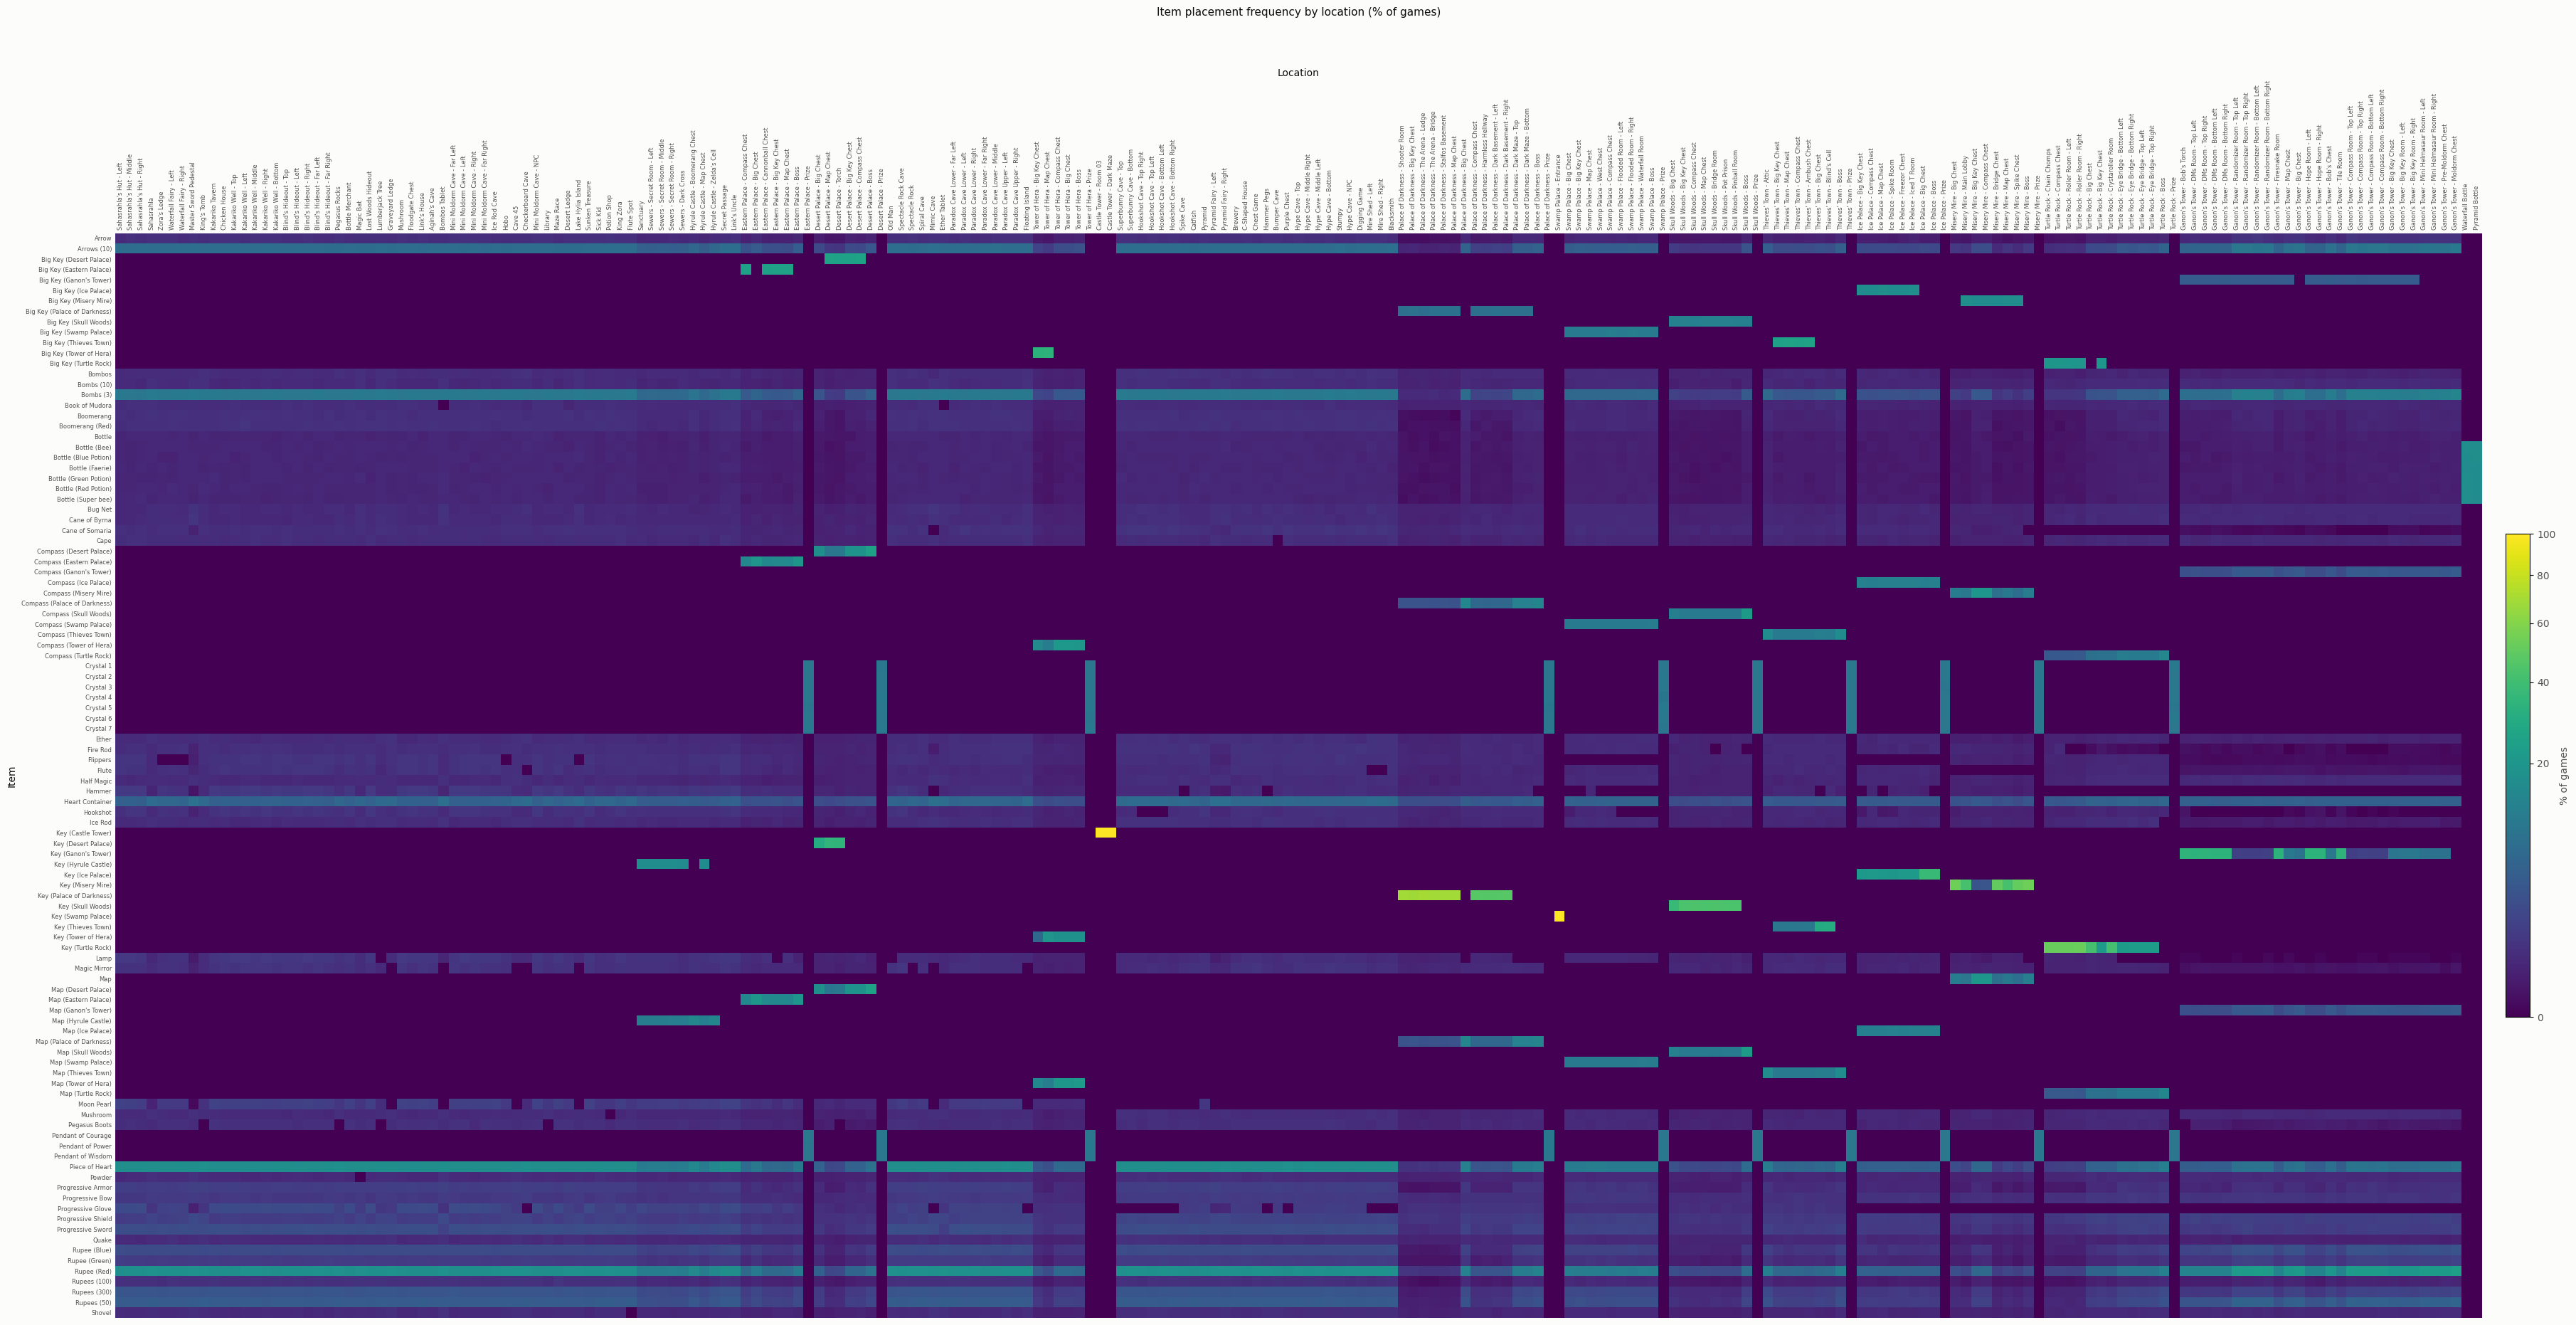

In [6]:
# full chart, every item and location

plot_item_heatmap(pct)
plt.show()

Instead we will filter out those locations:

Special locations -- bottle fills, dungeon prizes, Castle Tower, and the 1 chest in Swamp Palace that must be a small key in this mode

We'll also filter out dungeon items and rewards.

In [7]:
# Ignore:
#   dungeon prize locations (must be crystal 1-7 or pendant 1-3)
#   special locations (Faerie Fountains) where tossing an empty bottle fills it, not grants the actual item
#   Castle Tower locations only contains dungeon items -- not a keysanity seed
#   `Swamp Palace - Entrance` - Must be a key to get into the dungeon without keysanity enabled
SPECIAL_LOCATIONS = (
    ["Waterfall Bottle", "Pyramid Bottle"]
        + [loc for loc in item_cols if "Prize" in loc]
        + [loc for loc in item_cols if "Castle Tower" in loc]
        + ["Swamp Palace - Entrance"]
)

# Ignore crystals, pendants, keys, compasses, and maps in dungeons (not keysanity seeds)
DUNGEON_AND_BOSS_ITEMS = []
exclusions = ["key", "compass", "map", "crystal", "pendant"]
for item in unique_items:
    for exclusion in exclusions:
        if exclusion in item.lower():
            DUNGEON_AND_BOSS_ITEMS.append(item)


print("Special locations:", SPECIAL_LOCATIONS)
print("Dungeon items:", DUNGEON_AND_BOSS_ITEMS)

Special locations: ['Waterfall Bottle', 'Pyramid Bottle', 'Eastern Palace - Prize', 'Desert Palace - Prize', 'Tower of Hera - Prize', 'Palace of Darkness - Prize', 'Swamp Palace - Prize', 'Skull Woods - Prize', "Thieves' Town - Prize", 'Ice Palace - Prize', 'Misery Mire - Prize', 'Turtle Rock - Prize', 'Castle Tower - Room 03', 'Castle Tower - Dark Maze', 'Swamp Palace - Entrance']
Dungeon items: ['Big Key (Desert Palace)', 'Big Key (Eastern Palace)', "Big Key (Ganon's Tower)", 'Big Key (Ice Palace)', 'Big Key (Misery Mire)', 'Big Key (Palace of Darkness)', 'Big Key (Skull Woods)', 'Big Key (Swamp Palace)', 'Big Key (Thieves Town)', 'Big Key (Tower of Hera)', 'Big Key (Turtle Rock)', 'Compass (Desert Palace)', 'Compass (Eastern Palace)', "Compass (Ganon's Tower)", 'Compass (Ice Palace)', 'Compass (Misery Mire)', 'Compass (Palace of Darkness)', 'Compass (Skull Woods)', 'Compass (Swamp Palace)', 'Compass (Thieves Town)', 'Compass (Tower of Hera)', 'Compass (Turtle Rock)', 'Crystal 1', 'C

## Dungeons Filtered

This result looks better, but there's a really high set of percentages now for items that have multiple copies.

Hearts and Red Rupees are the most common items in the item pool, so it drowns out the other useful signal.

Also quite funny that it's almost guaranteed to get a bunch of Red Rupees at the end of the game in Ganon's Tower when you no longer need it.

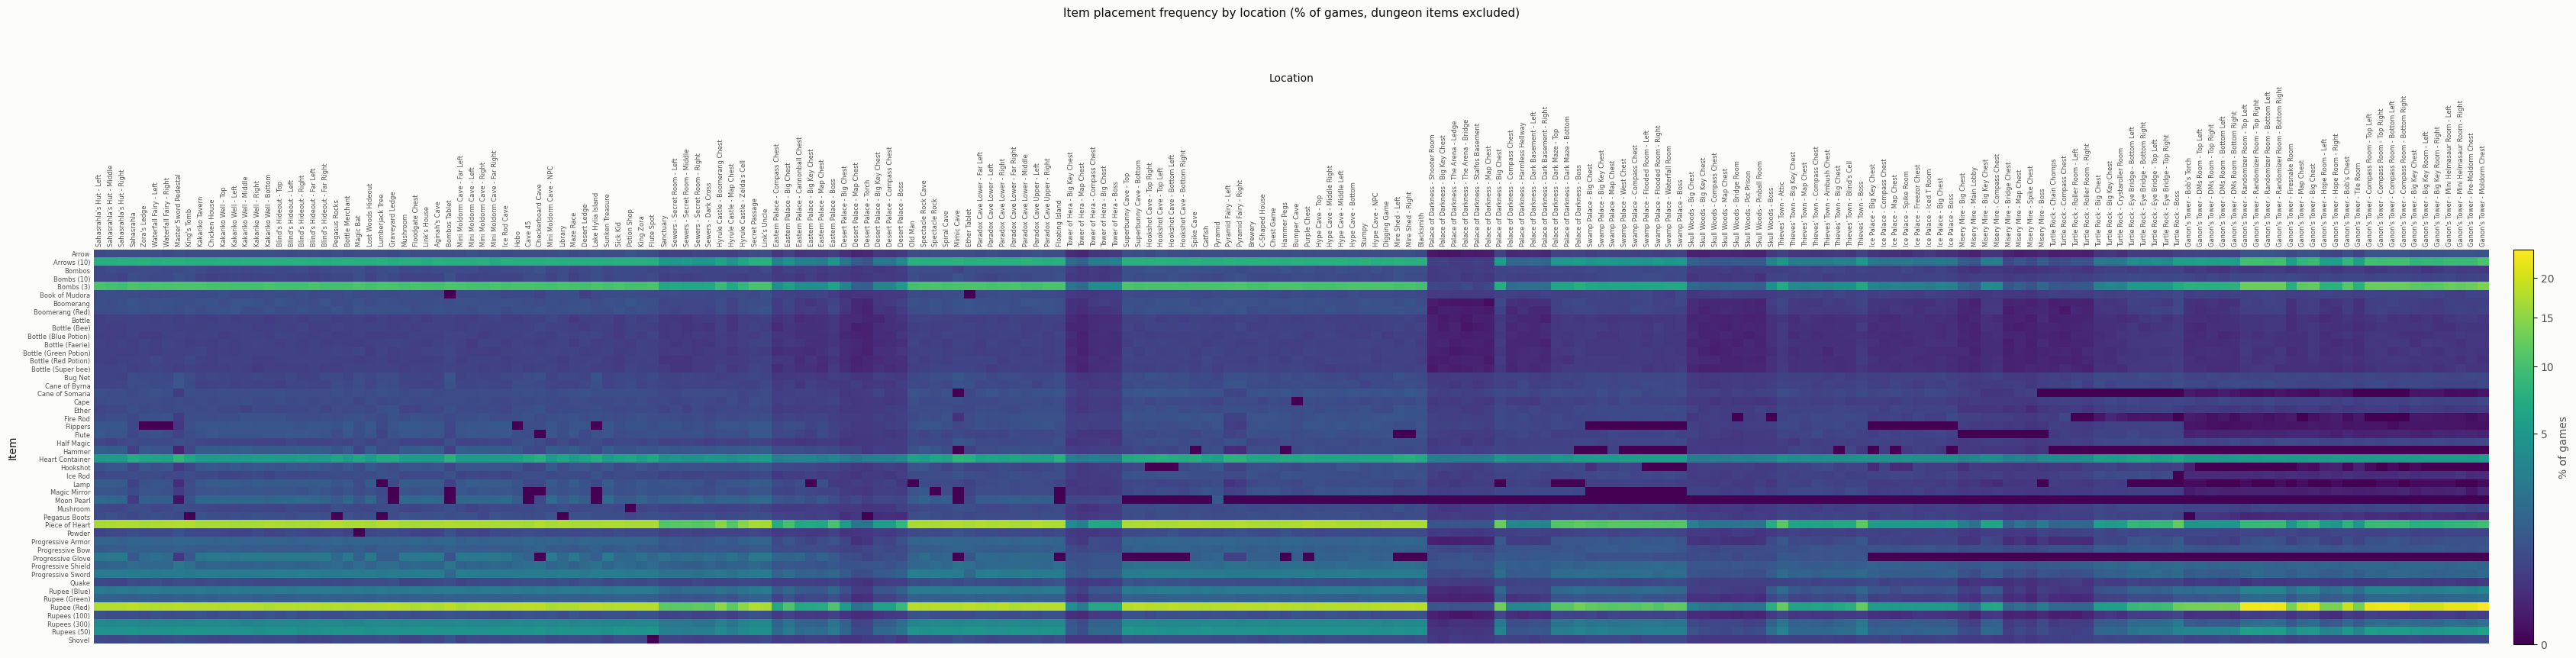

In [8]:
plot_item_heatmap(
    pct,
    exclude_items=DUNGEON_AND_BOSS_ITEMS,
    exclude_locations=SPECIAL_LOCATIONS,
    title="Item placement frequency by location (% of games, dungeon items excluded)",
    file_name="item_location_heatmap_no_dungeon_items.png",
)
plt.show()

To fix this we'll filter out anything that isn't an inventory item or a progressive item (progressive items have multiple copies and get stronger the more you collect, such as Fighters Sword -> Master Sword -> Tempered Sword -> Golden Sword)

That will still give us higher % for progressive items or bottles, but it's better than examining 40 copies of Heart Pieces or Rupees

In [9]:
# Ignore maps, compasses, keys, and consumables.
#
# Not every item is _always_ progression (like Ice Rod),
# and some are just powerups that make the game easier,
# (like Progressive items, Half Magic, filled Bottle types)

PROGRESSION_ITEMS = [
  "Bombos",
  "Book of Mudora",
  "Boomerang",
  "Boomerang (Red)",
  "Bottle",
  "Bottle (Bee)",
  "Bottle (Blue Potion)",
  "Bottle (Faerie)",
  "Bottle (Green Potion)",
  "Bottle (Red Potion)",
  "Bottle (Super bee)",
  "Bug Net",
  "Cane of Byrna",
  "Cane of Somaria",
  "Cape",
  "Ether",
  "Fire Rod",
  "Flippers",
  "Flute",
  "Half Magic",
  "Hammer",
  "Hookshot",
  "Ice Rod",
  "Lamp",
  "Magic Mirror",
  "Moon Pearl",
  "Mushroom",
  "Pegasus Boots",
  "Powder",
  "Progressive Armor",
  "Progressive Bow",
  "Progressive Glove",
  "Progressive Shield",
  "Progressive Sword",
  "Quake",
  "Shovel",
]

NON_PROGRESSION_ITEMS = [item for item in unique_items if item not in PROGRESSION_ITEMS]

NON_PROGRESSION_ITEMS

['Arrow',
 'Arrows (10)',
 'Big Key (Desert Palace)',
 'Big Key (Eastern Palace)',
 "Big Key (Ganon's Tower)",
 'Big Key (Ice Palace)',
 'Big Key (Misery Mire)',
 'Big Key (Palace of Darkness)',
 'Big Key (Skull Woods)',
 'Big Key (Swamp Palace)',
 'Big Key (Thieves Town)',
 'Big Key (Tower of Hera)',
 'Big Key (Turtle Rock)',
 'Bombs (10)',
 'Bombs (3)',
 'Compass (Desert Palace)',
 'Compass (Eastern Palace)',
 "Compass (Ganon's Tower)",
 'Compass (Ice Palace)',
 'Compass (Misery Mire)',
 'Compass (Palace of Darkness)',
 'Compass (Skull Woods)',
 'Compass (Swamp Palace)',
 'Compass (Thieves Town)',
 'Compass (Tower of Hera)',
 'Compass (Turtle Rock)',
 'Crystal 1',
 'Crystal 2',
 'Crystal 3',
 'Crystal 4',
 'Crystal 5',
 'Crystal 6',
 'Crystal 7',
 'Heart Container',
 'Key (Castle Tower)',
 'Key (Desert Palace)',
 "Key (Ganon's Tower)",
 'Key (Hyrule Castle)',
 'Key (Ice Palace)',
 'Key (Misery Mire)',
 'Key (Palace of Darkness)',
 'Key (Skull Woods)',
 'Key (Swamp Palace)',
 'Key (Th

## Progression Filtering

Finally have some useful signal here

Can see several low percentage locations:

- Sahasrahla (requires Green Pendant)
- Master Sword Pedestal (requires all Pendants)
- Bombos Tablet

We can also see isolated 0% chances -- exactly as we would expect because some items can't logically be placed in certain areas. Particularly: You'll never access Moon Pearl in a location that requires Dark World access, or Flippers in a location that requires swimming. You can also see horizontal lines for some items in dungeons that require that item (again, Flippers for Swamp Palace).

Several dungeon "blocks" exist -- this is an artifact of dungeons having keys which fill the chests in those locations. Particularly bad is Palace of Darkness, and you can see it's bimodal -- the front of PoD has 6 chests of which up to 4 can be keys, then the Big Chest has a fairly high probability of containing an item, followed by the back of PoD having a low chance again.

It might be interesting to group the locations by dungeon (would need to be normalized)

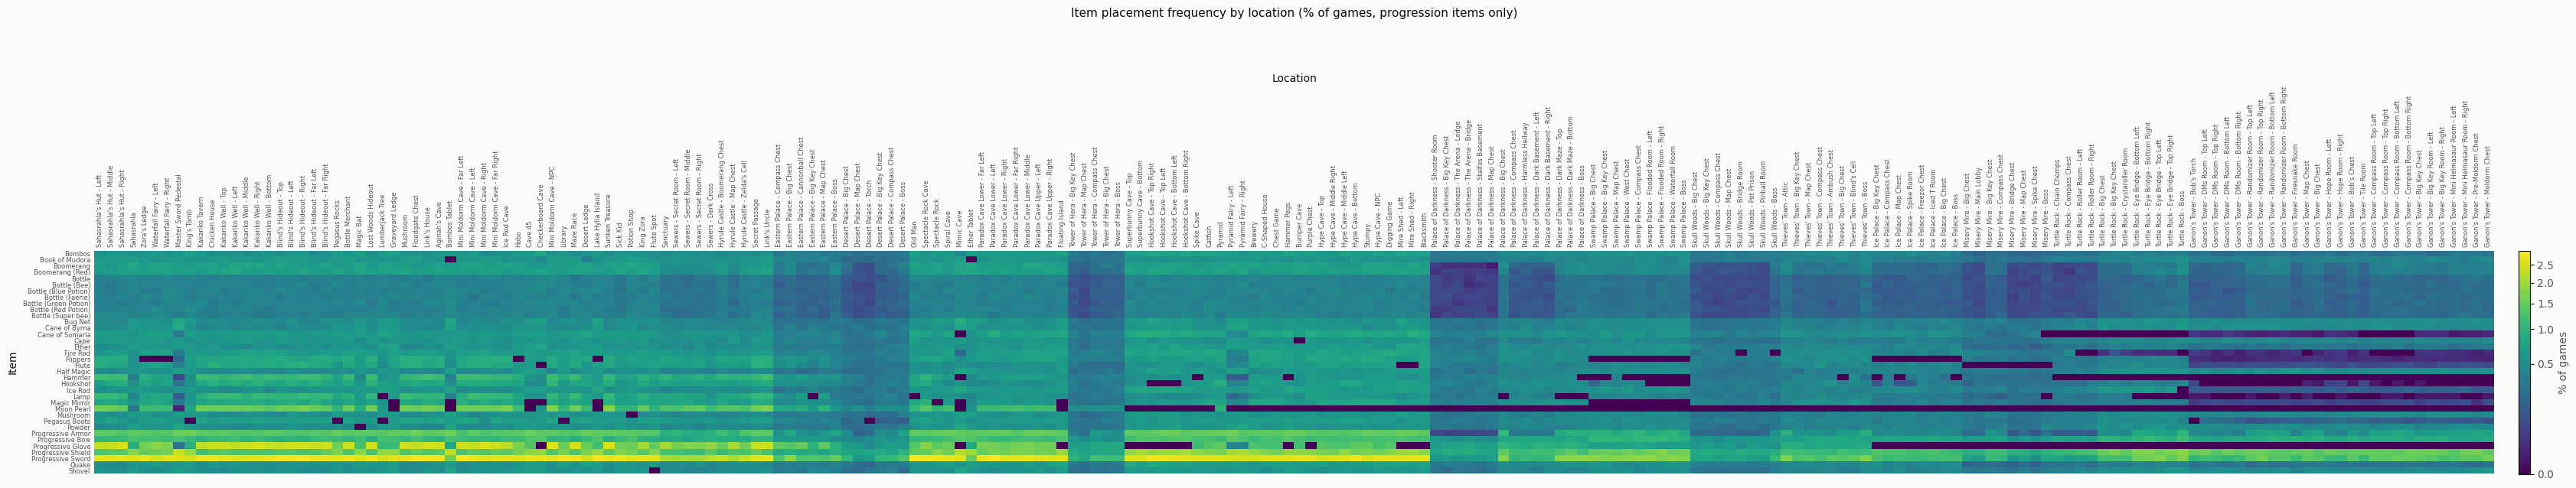

In [10]:
plot_item_heatmap(
    pct,
    exclude_items=NON_PROGRESSION_ITEMS,
    exclude_locations=SPECIAL_LOCATIONS,
    title="Item placement frequency by location (% of games, progression items only)",
    file_name="item_location_heatmap_progression_only.png",
)
plt.show()

## Outlier heatmap

Instead of raw placement %, is there a location where an item shows up far more
often than its own average -- e.g. is the Hammer more likely to land at one
particular spot than everywhere else?

For each item we compute the mean and standard deviation of its placement %
across all included locations (progression items only, `SPECIAL_LOCATIONS`
excluded, same filter as the heatmap above), then score every cell by how many
standard deviations it sits from that item's own average (z-score).

Same grid as the progression-only heatmap, recolored by z-score instead of raw
%: **blue** means an item lands there more often than its own average (a
positive outlier), **red** means less often, and near-white means about
average.

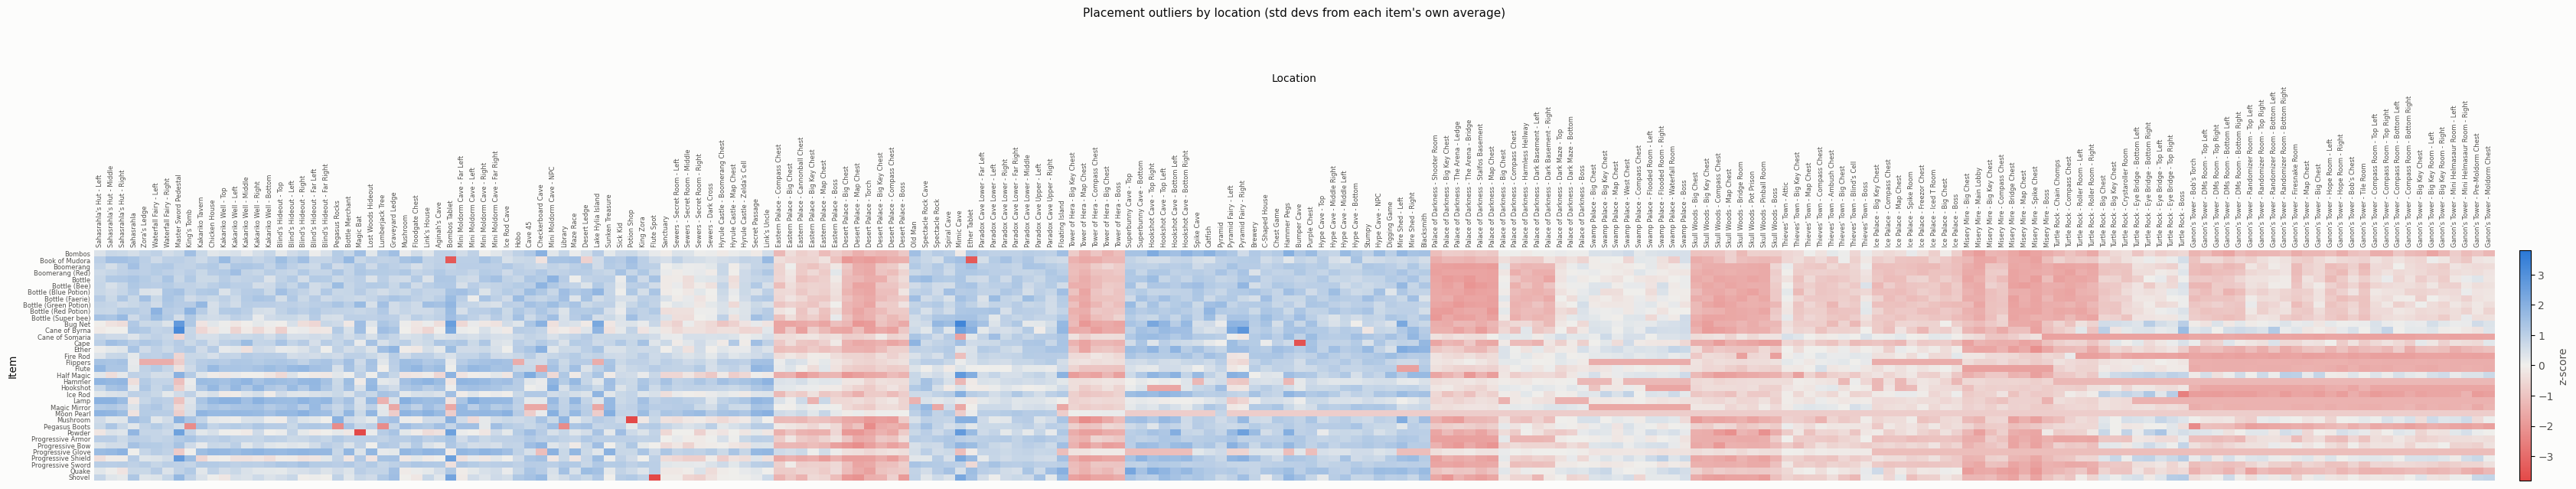

In [21]:
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap

OUTLIER_CMAP = LinearSegmentedColormap.from_list(
    "outlier_diverging", ["#e34948", "#f0efec", "#2a78d6"]
)
filtered = pct.loc[
    [item for item in pct.index if item not in NON_PROGRESSION_ITEMS],
    [loc for loc in item_cols if loc not in SPECIAL_LOCATIONS],
]

item_mean = filtered.mean(axis=1)
item_std = filtered.std(axis=1)
z_matrix = filtered.sub(item_mean, axis=0).div(item_std, axis=0)

z_bound = max(abs(z_matrix.values.min()), z_matrix.values.max())

plot_item_heatmap(
    z_matrix,
    title="Placement outliers by location (std devs from each item's own average)",
    cmap=OUTLIER_CMAP,
    norm=TwoSlopeNorm(vmin=-z_bound, vcenter=0, vmax=z_bound),
    colorbar_label="z-score",
    file_name="item_location_outlier_heatmap.png",
)
plt.show()

## Filtering out all dungeon locations

The two prior heatmaps show that there's a really huge chilling effect on item probability within dungeons. Let's filter those out for now:

In [19]:
DUNGEON_NAMES = [
    "Hyrule Castle",
    "Sewers",
    "Eastern Palace",
    "Desert Palace",
    "Tower of Hera",
    "Palace of Darkness",
    "Swamp Palace",
    "Thieves' Town", 
    "Skull Woods",
    "Ice Palace",
    "Misery Mire",
    "Turtle Rock",
    "Ganon's Tower"
]

DUNGEON_LOCATIONS = [loc for loc in item_cols if any(loc.startswith(name) for name in DUNGEON_NAMES)]

DUNGEON_LOCATIONS

['Sewers - Secret Room - Left',
 'Sewers - Secret Room - Middle',
 'Sewers - Secret Room - Right',
 'Sewers - Dark Cross',
 'Hyrule Castle - Boomerang Chest',
 'Hyrule Castle - Map Chest',
 "Hyrule Castle - Zelda's Cell",
 'Eastern Palace - Compass Chest',
 'Eastern Palace - Big Chest',
 'Eastern Palace - Cannonball Chest',
 'Eastern Palace - Big Key Chest',
 'Eastern Palace - Map Chest',
 'Eastern Palace - Boss',
 'Eastern Palace - Prize',
 'Desert Palace - Big Chest',
 'Desert Palace - Map Chest',
 'Desert Palace - Torch',
 'Desert Palace - Big Key Chest',
 'Desert Palace - Compass Chest',
 'Desert Palace - Boss',
 'Desert Palace - Prize',
 'Tower of Hera - Big Key Chest',
 'Tower of Hera - Map Chest',
 'Tower of Hera - Compass Chest',
 'Tower of Hera - Big Chest',
 'Tower of Hera - Boss',
 'Tower of Hera - Prize',
 'Palace of Darkness - Shooter Room',
 'Palace of Darkness - Big Key Chest',
 'Palace of Darkness - The Arena - Ledge',
 'Palace of Darkness - The Arena - Bridge',
 'Palac

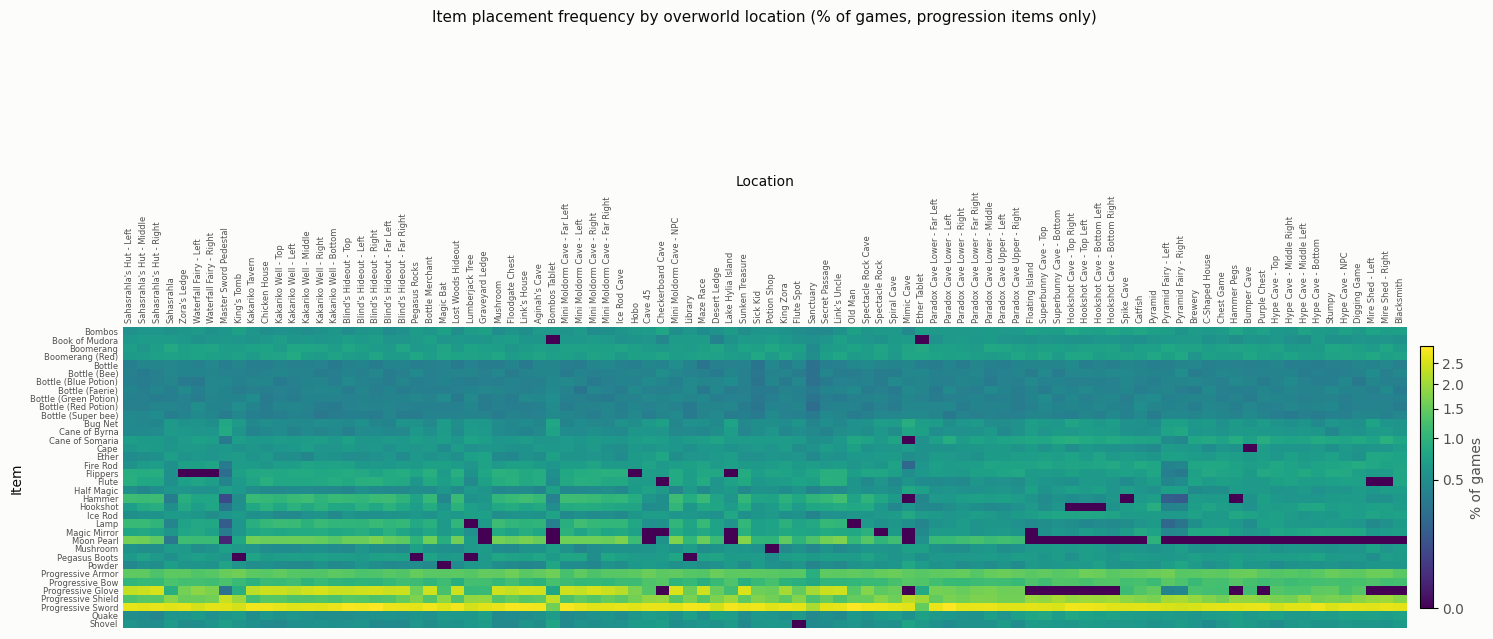

In [20]:
plot_item_heatmap(
    pct,
    exclude_items=NON_PROGRESSION_ITEMS,
    exclude_locations=set(SPECIAL_LOCATIONS + DUNGEON_LOCATIONS),
    title="Item placement frequency by overworld location (% of games, progression items only)",
    file_name="item_location_heatmap_overworld_progression_only.png",
)
plt.show()

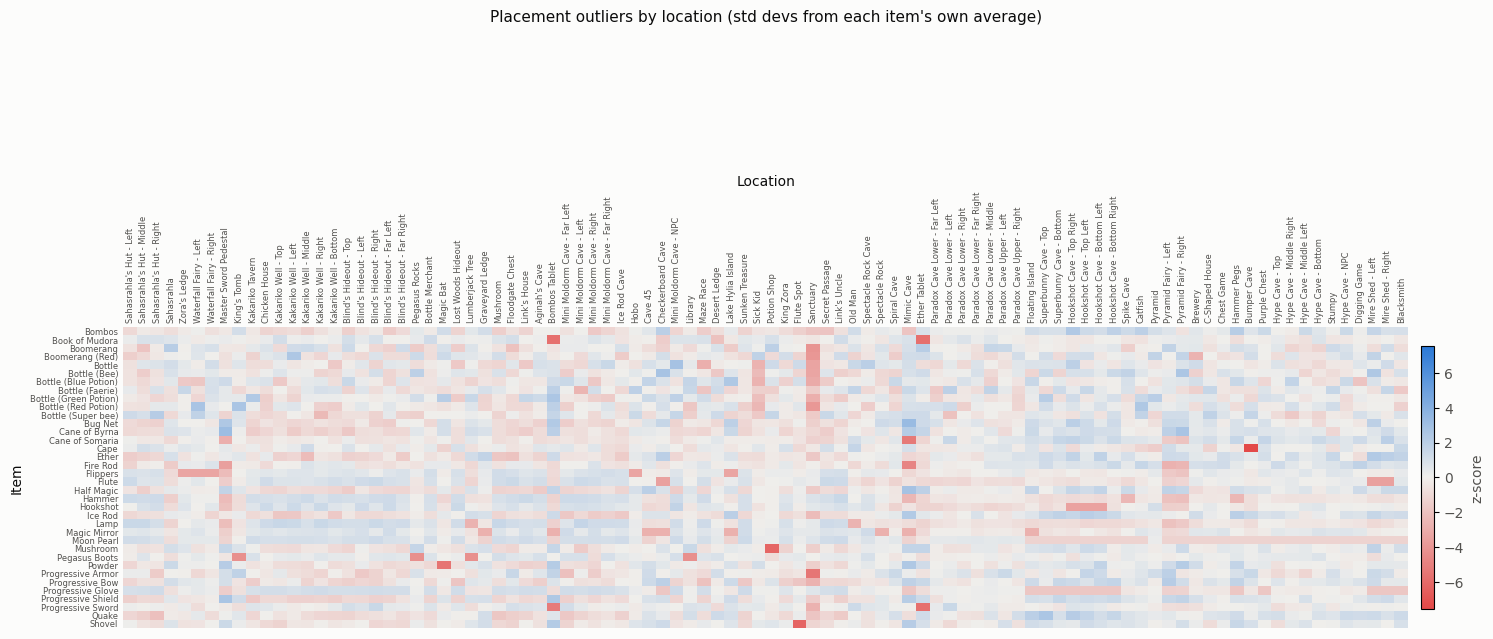

In [ ]:
filtered = pct.loc[
    [item for item in pct.index if item not in NON_PROGRESSION_ITEMS],
    [loc for loc in item_cols if loc not in set(SPECIAL_LOCATIONS + DUNGEON_LOCATIONS)],
]

item_mean = filtered.mean(axis=1)
item_std = filtered.std(axis=1)
z_matrix = filtered.sub(item_mean, axis=0).div(item_std, axis=0)

z_bound = max(abs(z_matrix.values.min()), z_matrix.values.max())

plot_item_heatmap(
    z_matrix,
    title="Placement outliers by overworld location (std devs from each item's own average)",
    cmap=OUTLIER_CMAP,
    norm=TwoSlopeNorm(vmin=-z_bound, vcenter=0, vmax=z_bound),
    colorbar_label="z-score",
    file_name="item_location_outlier_heatmap_no_dungeons.png",
)
plt.show()